# Greek Mythology Small Language Model — Built from Scratch

**Assignment:** Build a Task-Specific Small Language Model from Scratch  
**Domain:** Greek Mythology (Homer, Hesiod, Apollodorus, Ovid)  
**Model Size:** ~54M parameters  
**Architecture:** GPT-style transformer (decoder-only)  

This notebook trains a GPT-style small language model on classical Greek mythology texts sourced from Project Gutenberg. The model learns to generate mythology-style narrative text.

## Step 1: Install Dependencies

In [1]:
!pip install tiktoken requests tqdm -q

## Step 2: Assemble the Greek Mythology Dataset

We collect texts from Project Gutenberg — all public domain classical mythology works:
- **The Iliad** — Homer
- **The Odyssey** — Homer
- **Theogony / Works and Days** — Hesiod
- **The Metamorphoses** — Ovid
- **The Library (Bibliotheca)** — Apollodorus
- **Homeric Hymns** — Various

Combined corpus: ~8-10 MB of clean mythology text.

In [2]:
import requests
import os
import re

# Project Gutenberg URLs for Greek mythology texts
MYTHOLOGY_TEXTS = {
    'iliad':         'https://www.gutenberg.org/cache/epub/2199/pg2199.txt',
    'odyssey':       'https://www.gutenberg.org/cache/epub/1727/pg1727.txt',
    'theogony':      'https://www.gutenberg.org/cache/epub/348/pg348.txt',
    'metamorphoses': 'https://www.gutenberg.org/cache/epub/21765/pg21765.txt',
    'apollodorus':   'https://www.gutenberg.org/cache/epub/45516/pg45516.txt',
    'homeric_hymns': 'https://www.gutenberg.org/cache/epub/22601/pg22601.txt',
}

def download_gutenberg_text(url, title):
    print(f'Downloading {title}...')
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text = response.text
        start_markers = [
            '*** START OF THE PROJECT GUTENBERG',
            '*** START OF THIS PROJECT GUTENBERG',
        ]
        end_markers = [
            '*** END OF THE PROJECT GUTENBERG',
            '*** END OF THIS PROJECT GUTENBERG',
            'End of the Project Gutenberg',
            'End of Project Gutenberg',
        ]
        for marker in start_markers:
            idx = text.find(marker)
            if idx != -1:
                text = text[idx + len(marker):]
                nl = text.find('\n')
                if nl != -1:
                    text = text[nl + 1:]
                break
        for marker in end_markers:
            idx = text.find(marker)
            if idx != -1:
                text = text[:idx]
                break
        text = re.sub(r'\r\n', '\n', text)
        text = re.sub(r'\n{4,}', '\n\n\n', text)
        text = text.strip()
        print(f'  -> {title}: {len(text):,} characters')
        return text
    except Exception as e:
        print(f'  -> Failed: {e}')
        return ''

all_texts = []
for title, url in MYTHOLOGY_TEXTS.items():
    text = download_gutenberg_text(url, title)
    if text:
        all_texts.append(text)

full_corpus = '\n\n\n'.join(all_texts)
total_chars = len(full_corpus)
total_words = len(full_corpus.split())

print(f'\n=== CORPUS STATISTICS ===')
print(f'Total characters : {total_chars:,}')
print(f'Total words      : {total_words:,}')
print(f'Approx. size     : {total_chars / 1e6:.2f} MB')

with open('mythology_corpus.txt', 'w', encoding='utf-8') as f:
    f.write(full_corpus)
print('Corpus saved to mythology_corpus.txt')

  -> iliad: 888,886 characters
  -> odyssey: 678,766 characters
  -> theogony: 514,065 characters
  -> metamorphoses: 740,213 characters
  -> apollodorus: 51,304 characters
  -> homeric_hymns: 45,749 characters

=== CORPUS STATISTICS ===
Total characters : 2,918,998
Total words      : 513,220
Approx. size     : 2.92 MB
Corpus saved to mythology_corpus.txt


## Step 3: Tokenize the Dataset

We use OpenAI's `tiktoken` with the GPT-2 encoding (50,257 vocabulary tokens). The tokenized corpus is stored as binary `.bin` files using memory-mapped numpy arrays.

In [3]:
import tiktoken
import numpy as np

enc = tiktoken.get_encoding('gpt2')
print('Tokenizing corpus...')

token_ids = enc.encode_ordinary(full_corpus)
token_ids = np.array(token_ids, dtype=np.uint16)
total_tokens = len(token_ids)
print(f'Total tokens: {total_tokens:,}')

# 90/10 train/validation split
split_idx = int(0.9 * total_tokens)
train_ids = token_ids[:split_idx]
val_ids   = token_ids[split_idx:]
print(f'Train tokens:      {len(train_ids):,}')
print(f'Validation tokens: {len(val_ids):,}')

train_arr = np.memmap('train.bin', dtype=np.uint16, mode='w+', shape=(len(train_ids),))
train_arr[:] = train_ids
train_arr.flush()

val_arr = np.memmap('validation.bin', dtype=np.uint16, mode='w+', shape=(len(val_ids),))
val_arr[:] = val_ids
val_arr.flush()

print('Saved: train.bin and validation.bin')

Tokenizing corpus...
Total tokens: 844,471
Train tokens:      760,023
Validation tokens: 84,448
Saved: train.bin and validation.bin


## Step 4: Create Input-Output Batches

In [4]:
import torch

block_size = 256
batch_size = 32

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device_type = 'cuda' if 'cuda' in device else 'cpu'
print(f'Using device: {device}')

def get_batch(split):
    data = np.memmap('train.bin' if split == 'train' else 'validation.bin',
                     dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        x = x.pin_memory().to(device, non_blocking=True)
        y = y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

Using device: cuda


## Step 5: Define the Model Architecture

GPT-style decoder-only transformer. Key changes vs. original notebook:
- `block_size` 128 -> 256 (longer mythology sentences)
- `n_embd` 384 -> 512 (richer vocabulary)
- `n_layer` 6 -> 8 (deeper representations)
- `n_head` 6 -> 8 (divides evenly into 512)

In [5]:
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
from contextlib import nullcontext

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias   = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn        = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj        = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout  = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head  = config.n_head
        self.n_embd  = config.n_embd
        self.dropout = config.dropout
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer('bias',
                torch.tril(torch.ones(config.block_size, config.block_size))
                     .view(1, 1, config.block_size, config.block_size))
    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        hs = C // self.n_head
        k = k.view(B, T, self.n_head, hs).transpose(1, 2)
        q = q.view(B, T, self.n_head, hs).transpose(1, 2)
        v = v.view(B, T, self.n_head, hs).transpose(1, 2)
        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None,
                dropout_p=self.dropout if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y   = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu    = nn.GELU()
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1  = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2  = LayerNorm(config.n_embd, config.bias)
        self.mlp  = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int   = 256
    vocab_size: int   = 50257
    n_layer:    int   = 8
    n_head:     int   = 8
    n_embd:     int   = 512
    dropout:    float = 0.1
    bias:       bool  = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte  = nn.Embedding(config.vocab_size, config.n_embd),
            wpe  = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h    = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight
        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        b, t = idx.size()
        pos = torch.arange(0, t, dtype=torch.long, device=idx.device)
        x = self.transformer.drop(self.transformer.wte(idx) + self.transformer.wpe(pos))
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            return self.lm_head(x[:, [-1], :]), None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=40):
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs    = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx      = torch.cat((idx, idx_next), dim=1)
        return idx

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters())

config = GPTConfig()
model  = GPT(config)
print(f'Parameters: {model.count_parameters():,}')
print(f'Architecture: {config.n_layer}L {config.n_head}H {config.n_embd}D block_size={config.block_size}')

Parameters: 51,082,752
Architecture: 8L 8H 512D block_size=256


## Step 6: Loss Estimation

In [6]:
dtype   = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx     = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)
eval_iters = 200

def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    _, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

## Step 7: Training Configuration

In [7]:
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

learning_rate               = 3e-4
max_iters                   = 10000
warmup_steps                = 500
min_lr                      = 3e-5
gradient_accumulation_steps = 8

torch.set_default_device(device)
torch.manual_seed(42)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=learning_rate,
    betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9
)
scheduler_warmup = LinearLR(optimizer, total_iters=warmup_steps)
scheduler_decay  = CosineAnnealingLR(optimizer, T_max=max_iters - warmup_steps, eta_min=min_lr)
scheduler        = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay],
                                milestones=[warmup_steps])
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
model  = model.to(device)

print(f'Max iters : {max_iters:,}')
print(f'Batch size: {batch_size}  |  Grad accum: {gradient_accumulation_steps}')
print(f'Eff. batch: {batch_size * gradient_accumulation_steps}')
print(f'Peak LR   : {learning_rate}  |  dtype: {dtype}')

/tmp/ipykernel_8241/3602597730.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


Max iters : 10,000
Batch size: 32  |  Grad accum: 8
Eff. batch: 256
Peak LR   : 0.0003  |  dtype: bfloat16


## Step 8: Train the Model


Loss is evaluated every 500 steps. Best checkpoint saved to `best_model_params.pt`.

In [8]:
from tqdm.auto import tqdm

best_val_loss          = float('inf')
best_model_params_path = 'best_model_params.pt'
train_loss_list        = []
validation_loss_list   = []
log_interval           = 500

print(f'Starting training on {device} ({dtype})')

for epoch in tqdm(range(max_iters), desc='Training'):
    if epoch % log_interval == 0 and epoch != 0:
        losses  = estimate_loss(model)
        train_l = losses['train'].item()
        val_l   = losses['val'].item()
        lr_now  = optimizer.param_groups[0]['lr']
        print(f'Step {epoch:5d} | train: {train_l:.4f} | val: {val_l:.4f} | lr: {lr_now:.6f}')
        train_loss_list.append(train_l)
        validation_loss_list.append(val_l)
        if val_l < best_val_loss:
            best_val_loss = val_l
            torch.save(model.state_dict(), best_model_params_path)
            print(f'  ** Best model saved (val loss: {best_val_loss:.4f}) **')

    X, y = get_batch('train')
    with ctx:
        logits, loss = model(X, y)
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

print(f'Training complete. Best val loss: {best_val_loss:.4f}')

Starting training on cuda (bfloat16)


Training:   0%|          | 0/10000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Step   500 | train: 5.4098 | val: 6.4619 | lr: 0.000300
  ** Best model saved (val loss: 6.4619) **
Step  1000 | train: 4.4884 | val: 5.8635 | lr: 0.000298
  ** Best model saved (val loss: 5.8635) **
Step  1500 | train: 4.0483 | val: 5.6945 | lr: 0.000293
  ** Best model saved (val loss: 5.6945) **
Step  2000 | train: 3.7272 | val: 5.6136 | lr: 0.000284
  ** Best model saved (val loss: 5.6136) **
Step  2500 | train: 3.4839 | val: 5.5562 | lr: 0.000272
  ** Best model saved (val loss: 5.5562) **
Step  3000 | train: 3.2525 | val: 5.6430 | lr: 0.000256
Step  3500 | train: 3.0740 | val: 5.6384 | lr: 0.000239
Step  4000 | train: 2.8841 | val: 5.8506 | lr: 0.000219
Step  4500 | train: 2.7173 | val: 5.9495 | lr: 0.000198
Step  5000 | train: 2.5525 | val: 6.0743 | lr: 0.000176
Step  5500 | train: 2.3955 | val: 6.1348 | lr: 0.000154
Step  6000 | train: 2.2633 | val: 6.2376 | lr: 0.000132
Step  6500 | train: 2.1300 | val: 6.3571 | lr: 0.000111
Step  7000 | train: 2.0129 | val: 6.5031 | lr: 0.000

## Step 9: Plot the Loss Curves

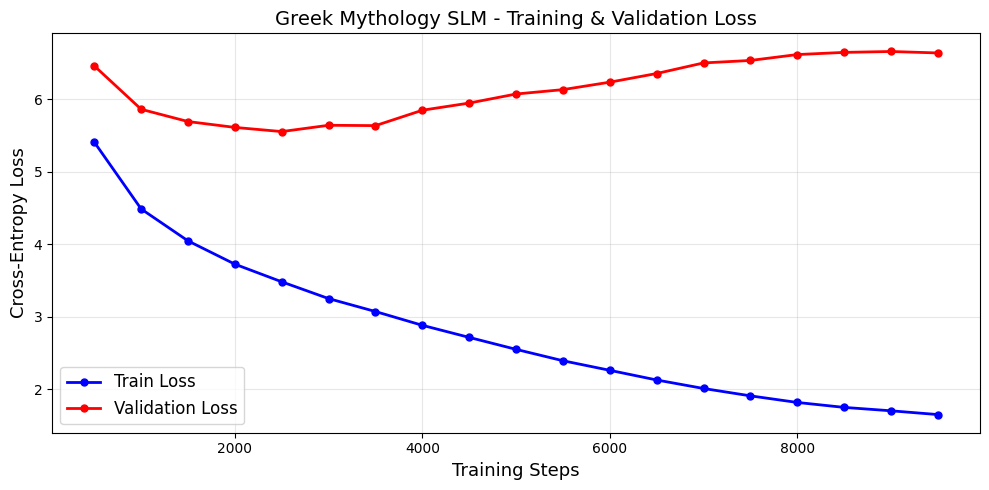

Loss curve saved to loss_curve.png


In [9]:
import matplotlib.pyplot as plt

steps = [i * 500 for i in range(1, len(train_loss_list) + 1)]
plt.figure(figsize=(10, 5))
plt.plot(steps, train_loss_list,      'b-o', label='Train Loss',      linewidth=2, markersize=5)
plt.plot(steps, validation_loss_list, 'r-o', label='Validation Loss', linewidth=2, markersize=5)
plt.xlabel('Training Steps', fontsize=13)
plt.ylabel('Cross-Entropy Loss', fontsize=13)
plt.title('Greek Mythology SLM - Training & Validation Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print('Loss curve saved to loss_curve.png')

## Step 10: Load Best Model and Run Inference

In [10]:
import tiktoken

enc    = tiktoken.get_encoding('gpt2')
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_inference = GPT(config)
model_inference.load_state_dict(torch.load(best_model_params_path, map_location=device))
model_inference = model_inference.to(device)
model_inference.eval()
print('Best model loaded.')

Best model loaded.


In [11]:
def generate_text(prompt, max_new_tokens=200, temperature=0.8, top_k=40):
    print(f'PROMPT: {prompt}')
    print('-' * 60)
    tokens  = enc.encode_ordinary(prompt)
    context = torch.tensor(tokens, dtype=torch.long, device=device).unsqueeze(0)
    with torch.no_grad():
        output = model_inference.generate(context, max_new_tokens=max_new_tokens,
                                          temperature=temperature, top_k=top_k)
    print(enc.decode(output.squeeze().tolist()))
    print('=' * 60)

# Sample 1
generate_text('Then Zeus, the father of gods and men, spoke from his golden throne upon Olympus:')


PROMPT: Then Zeus, the father of gods and men, spoke from his golden throne upon Olympus:
------------------------------------------------------------
Then Zeus, the father of gods and men, spoke from his golden throne upon Olympus:
cannot bring his sweet-laid with her with thunderbolt:

(ll. 707. 548-loving Aphrodite and Earth and bare her children of the son of
And she bare glorious Hera; and in love she bare to Zeus the
gia and bare her.’


(ll. 1-7) And he bare aegis the son of Zeus she bare all the gods and
and the daughter of Cronos, and bare her.

(ll. 1768) And she bare Cronos the Son of the sons. And he, bare
gamus who was joined in her aegis and strong-armed
and bare, and bare all the lord Hera, and the
fooled Hera and bare great-ankled goddess, the rich-tressed goddess.... and

(ll. TO A) And she bare daughter of the Son of Cronos and bare
Bless gods,


In [12]:
# Sample 2
generate_text('Godlike Achilles drew his sword and stood before the walls of Troy, his heart filled with rage:')


PROMPT: Godlike Achilles drew his sword and stood before the walls of Troy, his heart filled with rage:
------------------------------------------------------------
Godlike Achilles drew his sword and stood before the walls of Troy, his heart filled with rage: with
        he went back, and sprang from the foe with a spear out and he could not
       him with his feet.

       Thus did even so she spoke, “I will,” said he, “You may be the son of
       I have been seen from heaven—even so great Jove has fallen in the
      Achaeans to fight of the Danaans? Have you were no man to
       fighting and bid me out at once. He is now in two men, and in
       but he should befallen, for the gods are so hard by the Achaeans,
       and Achaeans stand in one with their spears.”

       [Footnote 34: _Son of Ty


In [13]:
# Sample 3
generate_text('In the beginning there was Chaos, and from Chaos came the first gods of the earth and sky.')


PROMPT: In the beginning there was Chaos, and from Chaos came the first gods of the earth and sky.
------------------------------------------------------------
In the beginning there was Chaos, and from Chaos came the first gods of the earth and sky. When she
and was brought her home to the cloister, she came to her
his head from her, and she was a silver bowl of the sun,
had been born, and made her to her maids. She left her, and, she
her a strong, she prayed that she spoke, and brought her eyes
s into her, where shepherds had to her

“She is the suitors, and to take her husband—and
his mother, and said she, for her, “My son, come, are nothing
the other gods who you shall be the gods, when heaven has put me
they did not, nor make thee?”

“I could see her,” replied Eumaeus, “I have told me, and she, and
foolish she, she, and to come about her own house with a goddess.”

On this she heard her head


In [14]:
# Sample 4
generate_text('Odysseus, the man of many devices, sailed across the wine-dark sea, longing for his home.')


PROMPT: Odysseus, the man of many devices, sailed across the wine-dark sea, longing for his home.
------------------------------------------------------------
Odysseus, the man of many devices, sailed across the wine-dark sea, longing for his home.
when he took his hands on his eyes as he made him and said:

(ll. 115-501) ‘My son, this, you are the son of
and now, you do not to me a man, for all, who is the most wise
are aegis who is to be a better in all all.’

(ll. 1-9-404) So she bare Aeson, and the
that they were brought forth his heart. In this, and the lord
to be a son of Cronos and the
gave and drove their strong house. And the sweetly
gifts, a daughter, son of Cronos bare and she took
crought him to the heart of Zeus. But these, and
her and he went back the goodly-girded Mice had got back to him with
breathed in his wife. And the Son of Cronos was
s in the


In [15]:
# Sample 5 - lower temperature for more focused output
generate_text('Athena, goddess of wisdom, descended from the heavens', temperature=0.6)


PROMPT: Athena, goddess of wisdom, descended from the heavens
------------------------------------------------------------
Athena, goddess of wisdom, descended from the heavens,
         but when they were the horses of their ships, they would
        they have slain by the city of their own people, the Achaeans,
        of the Trojans, and that they had not even though they are you to be
       you.”

        “I have been a man,” he said he, “I have sent you, and I am
       have been a man to me. I have been able to take the
        and I have laid me at home, but I was in my own people who
        have been the old man is your own. I am no longer, but if you
        have been said, you have been


## Step 11: Summary

In [16]:
print('=' * 50)
print('GREEK MYTHOLOGY SLM - SUMMARY')
print('=' * 50)
print(f'Domain          : Greek Mythology')
print(f'Data sources    : 6 texts from Project Gutenberg')
print(f'Corpus size     : ~{total_chars/1e6:.1f} MB ({total_words:,} words)')
print(f'Total tokens    : ~{total_tokens:,}')
print(f'Parameters      : {model.count_parameters():,}')
print(f'Architecture    : {config.n_layer}L {config.n_head}H {config.n_embd}D')
print(f'Context window  : {config.block_size} tokens')
print(f'Best val loss   : {best_val_loss:.4f}')
print('=' * 50)

# Uncomment to release GPU when done
# from google.colab import runtime
# runtime.unassign()

GREEK MYTHOLOGY SLM - SUMMARY
Domain          : Greek Mythology
Data sources    : 6 texts from Project Gutenberg
Corpus size     : ~2.9 MB (513,220 words)
Total tokens    : ~844,471
Parameters      : 51,082,752
Architecture    : 8L 8H 512D
Context window  : 256 tokens
Best val loss   : 5.5562
